In [1]:
# Import Libraries
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree # Changed to Regressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score # Adjusted metrics for regression
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy to use sqrt

# Load Dataset
df = pd.read_csv("teen_phone_addiction_dataset.csv")

AttributeError: module 'pandas' has no attribute 'DataFrame' (consider renaming 'C:\Users\Lenovo\Downloads\Downloads-20251229T140614Z-1-001\TNS\pandas.py' if it has the same name as a library you intended to import)

In [2]:
# Basic Info
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# Drop missing values
df = df.dropna()

# Assume the last column is the target
# df['target_col_name'] = df['Addiction_Level']
# print("\nTarget Column:", df['target_col_name'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [3]:
target_col_name = 'Addiction_Level'
# Check value counts of the target variable (still useful for understanding distribution)
print("\nTarget variable value counts:\n", df[target_col_name].value_counts())
df['Addiction_Level'] = df['Addiction_Level'].astype(int)


Target variable value counts:
 Addiction_Level
10.0    1524
9.9       50
9.6       46
8.0       45
7.8       45
        ... 
2.0        1
2.2        1
2.3        1
1.0        1
3.6        1
Name: count, Length: 80, dtype: int64


In [4]:
# Method: 2
# # Convert numeric Addiction_Level into categories
# bins = [0, 3, 6, 10]  # ranges for Low, Medium, High
# labels = ["Low", "Medium", "High"]
# df["Addiction_Category"] = pd.cut(df["Addiction_Level"], bins=bins, labels=labels, include_lowest=True)

# # Set target column
# target_col = "Addiction_Category"

# Encode categorical features
le = LabelEncoder()

In [5]:
#26-03-2026
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level'],
      dtype='object')

In [6]:
cols = df.select_dtypes(include='object').columns
cols


Index(['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose'], dtype='object')

In [7]:
# Encode categorical features
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

In [8]:
df.corr()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
ID,1.000000,-0.004587,-0.035674,-0.009726,0.012011,0.005384,-0.004700,0.018254,-0.013589,-0.041130,...,0.004300,-0.037117,-0.004608,0.017989,0.014501,-0.000726,-0.000400,-0.019269,0.018583,-0.008126
Name,-0.004587,1.000000,-0.016291,-0.003517,0.019892,0.015464,-0.016684,-0.005477,-0.013337,0.007496,...,0.004970,0.029197,-0.017901,-0.006883,-0.003888,-0.006905,0.021518,-0.018623,0.014761,-0.018978
Age,-0.035674,-0.016291,1.000000,-0.013583,-0.016589,-0.017654,0.040689,0.014725,0.023481,-0.020240,...,0.007213,-0.008696,-0.003000,-0.005100,-0.008967,0.008372,0.009273,-0.003813,0.002801,0.026876
Gender,-0.009726,-0.003517,-0.013583,1.000000,-0.006315,-0.005795,-0.020679,-0.008885,0.020561,-0.004449,...,0.001998,-0.008985,0.023141,-0.005942,-0.045998,-0.056161,-0.001399,-0.014056,-0.010164,-0.028972
Location,0.012011,0.019892,-0.016589,-0.006315,1.000000,-0.013417,-0.009590,-0.008540,-0.018677,0.033795,...,0.021443,0.012030,-0.004985,-0.005485,0.011244,0.001922,-0.005799,0.004673,-0.010639,0.012758
School_Grade,0.005384,0.015464,-0.017654,-0.005795,-0.013417,1.000000,0.008075,0.026486,0.005392,-0.003166,...,-0.010093,-0.003153,-0.031940,-0.001775,0.036261,0.006082,-0.019496,-0.022698,0.006149,-0.004208
Daily_Usage_Hours,-0.004700,-0.016684,0.040689,-0.020679,-0.009590,0.008075,1.000000,0.016444,0.021345,-0.030383,...,0.004935,0.004749,0.022841,-0.012620,-0.010371,0.014265,-0.019900,0.004427,0.019551,0.611961
Sleep_Hours,0.018254,-0.005477,0.014725,-0.008885,-0.008540,0.026486,0.016444,1.000000,-0.000273,-0.017898,...,-0.004313,0.005198,0.026436,-0.018288,0.005798,-0.009756,-0.007392,-0.027040,-0.003670,-0.222390
Academic_Performance,-0.013589,-0.013337,0.023481,0.020561,-0.018677,0.005392,0.021345,-0.000273,1.000000,0.011815,...,-0.005825,-0.017102,-0.026136,0.036357,-0.033734,0.016377,-0.014884,-0.027859,0.014263,0.013238
Social_Interactions,-0.041130,0.007496,-0.020240,-0.004449,0.033795,-0.003166,-0.030383,-0.017898,0.011815,1.000000,...,-0.019066,0.011992,-0.025440,0.002776,-0.004920,-0.008254,-0.013318,0.004239,-0.021410,-0.013507


Text(0.5, 1.0, 'Correlation Heatmap')

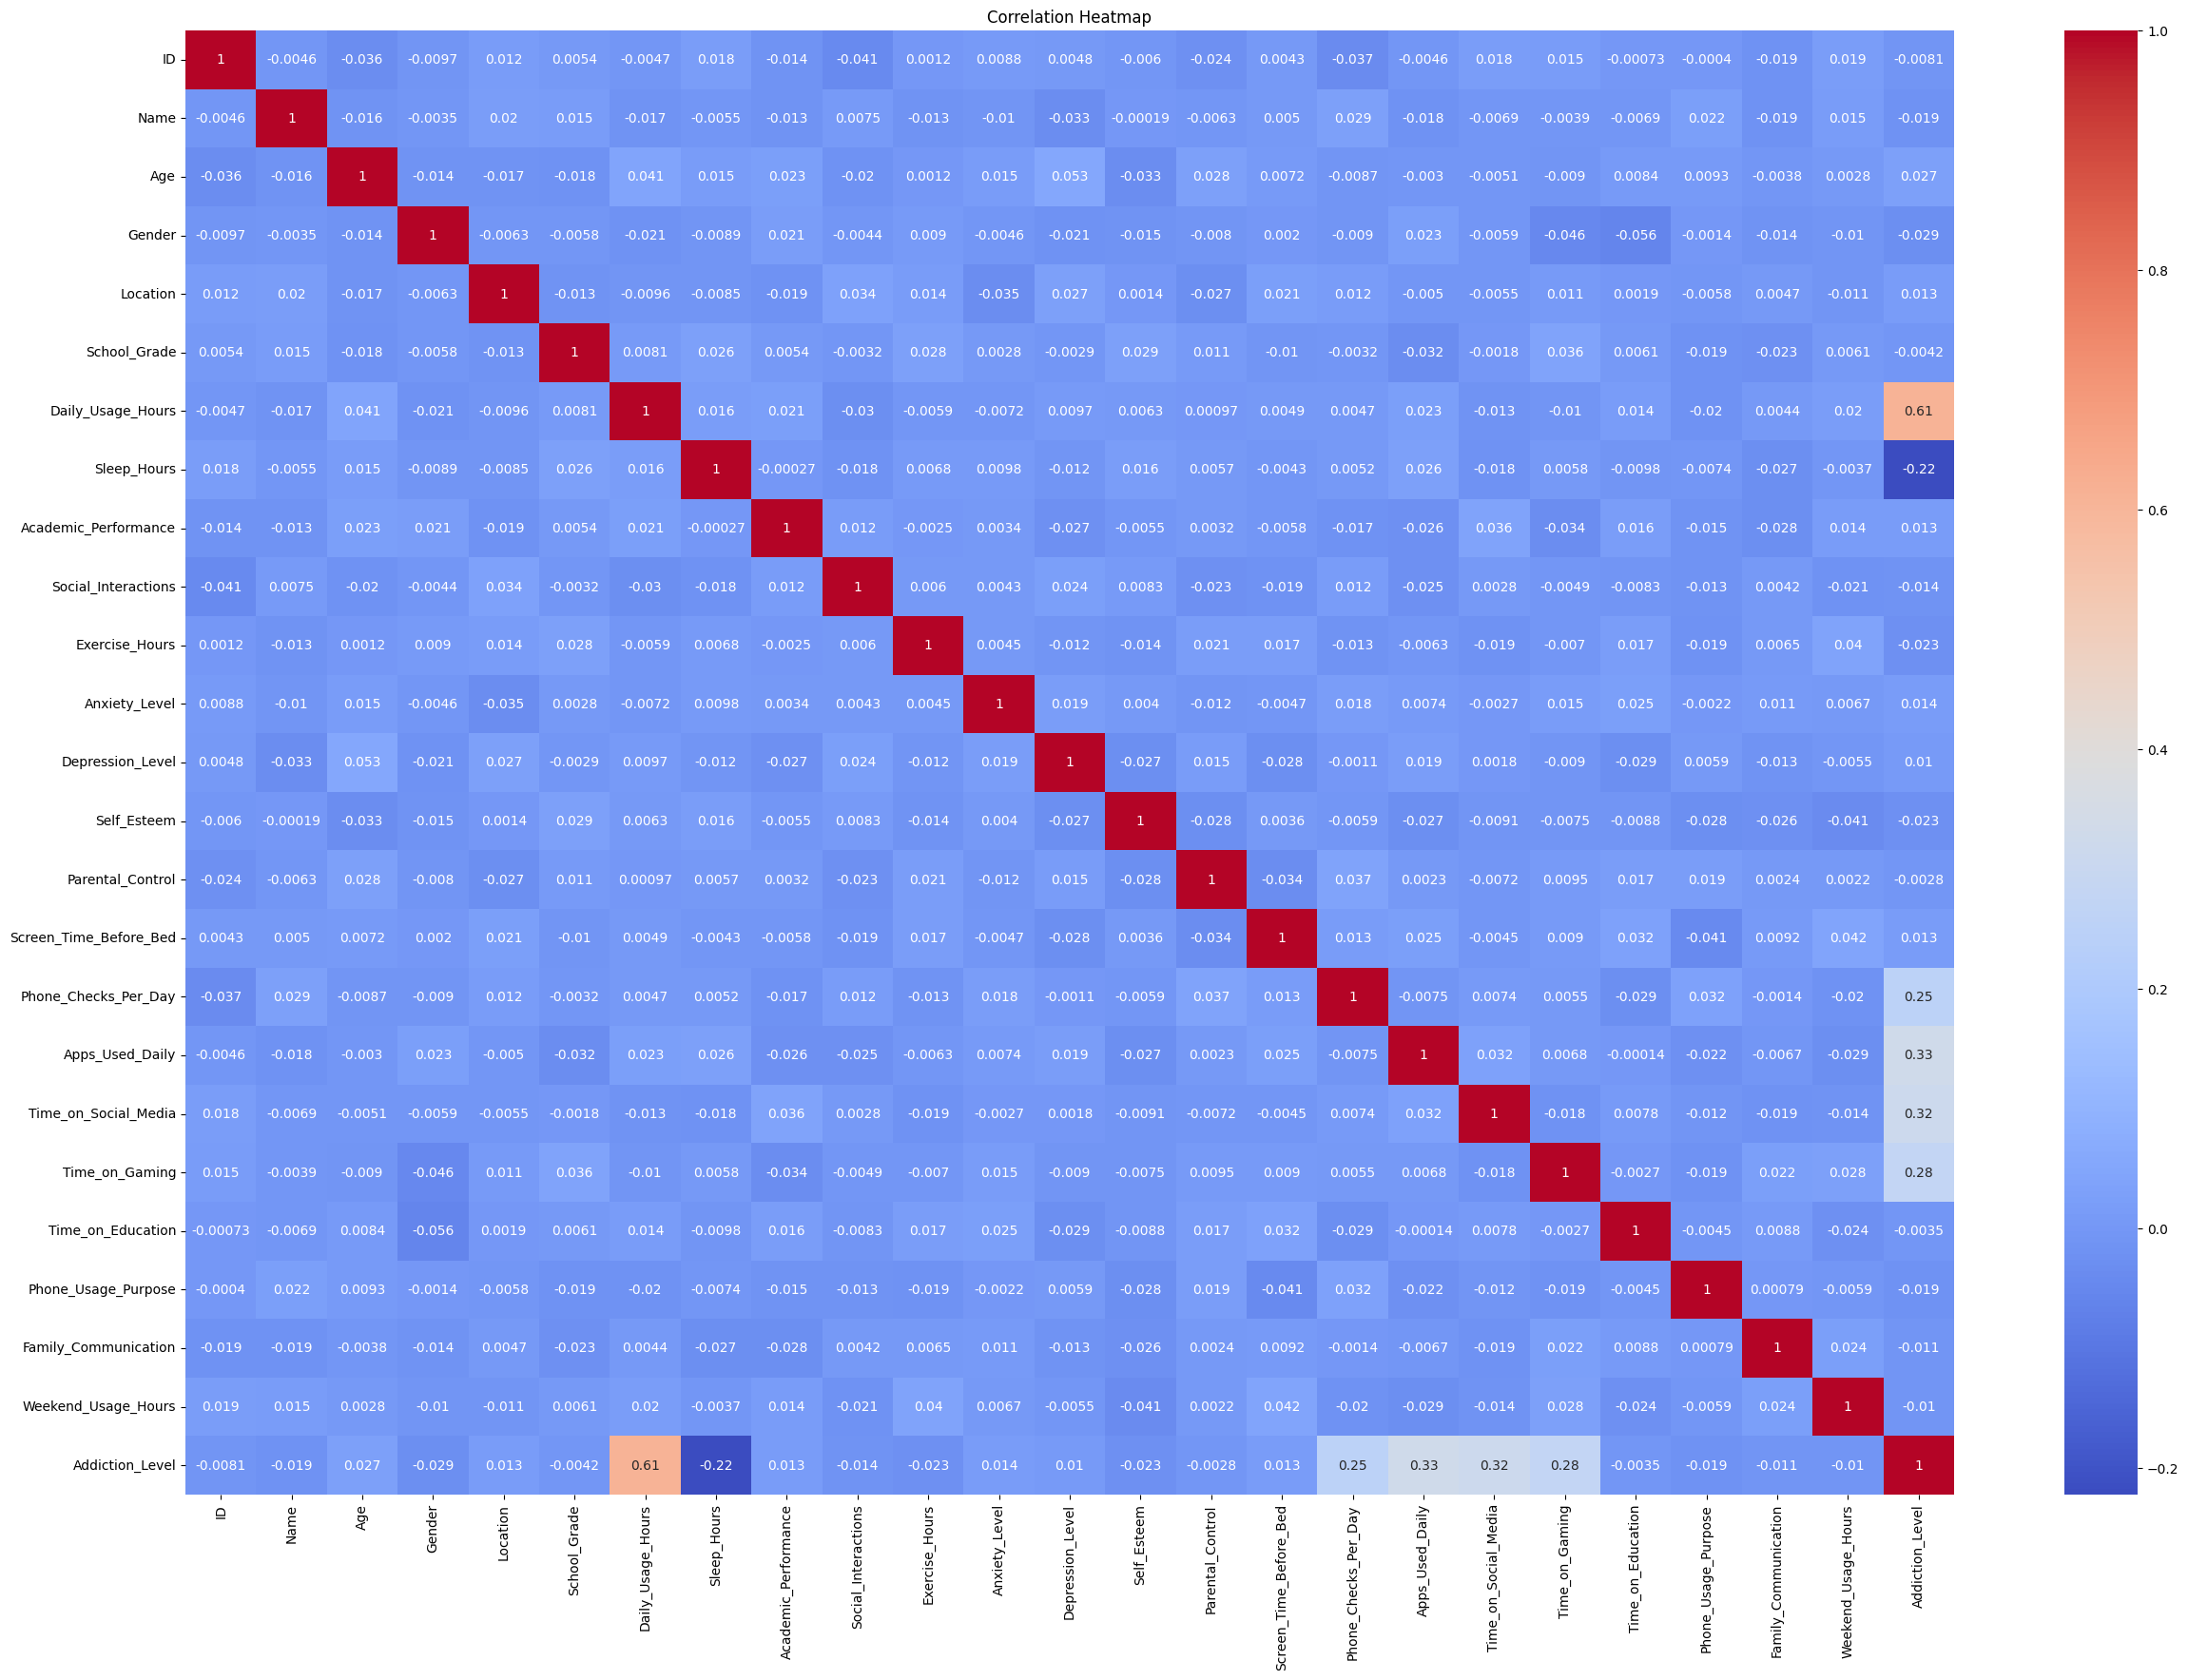

In [9]:
# Correlation Heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

In [10]:
# Feature/Target Split
y = df['Addiction_Level']
X = df.drop(columns='Addiction_Level')


# Train-Test Split (removed stratify as it's not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# GridSearchCV for Hyperparameter Tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
print("\nBest Parameters:", grid.best_params_)

C:\Users\Shrutika Walunj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}


In [12]:
#Train Best Model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [13]:
#Evalution 
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:",acc)
print("\nClassification Report:\n",classification_report(y_test,y_pred))



Accuracy: 0.5316666666666666

Classification Report:
               precision    recall  f1-score   support

           2       0.00      0.00      0.00         2
           3       0.50      0.12      0.20         8
           4       0.08      0.11      0.10         9
           5       0.24      0.20      0.22        20
           6       0.19      0.18      0.19        44
           7       0.21      0.20      0.20        61
           8       0.30      0.37      0.33        70
           9       0.20      0.20      0.20        81
          10       0.83      0.82      0.83       305

    accuracy                           0.53       600
   macro avg       0.28      0.25      0.25       600
weighted avg       0.54      0.53      0.53       600



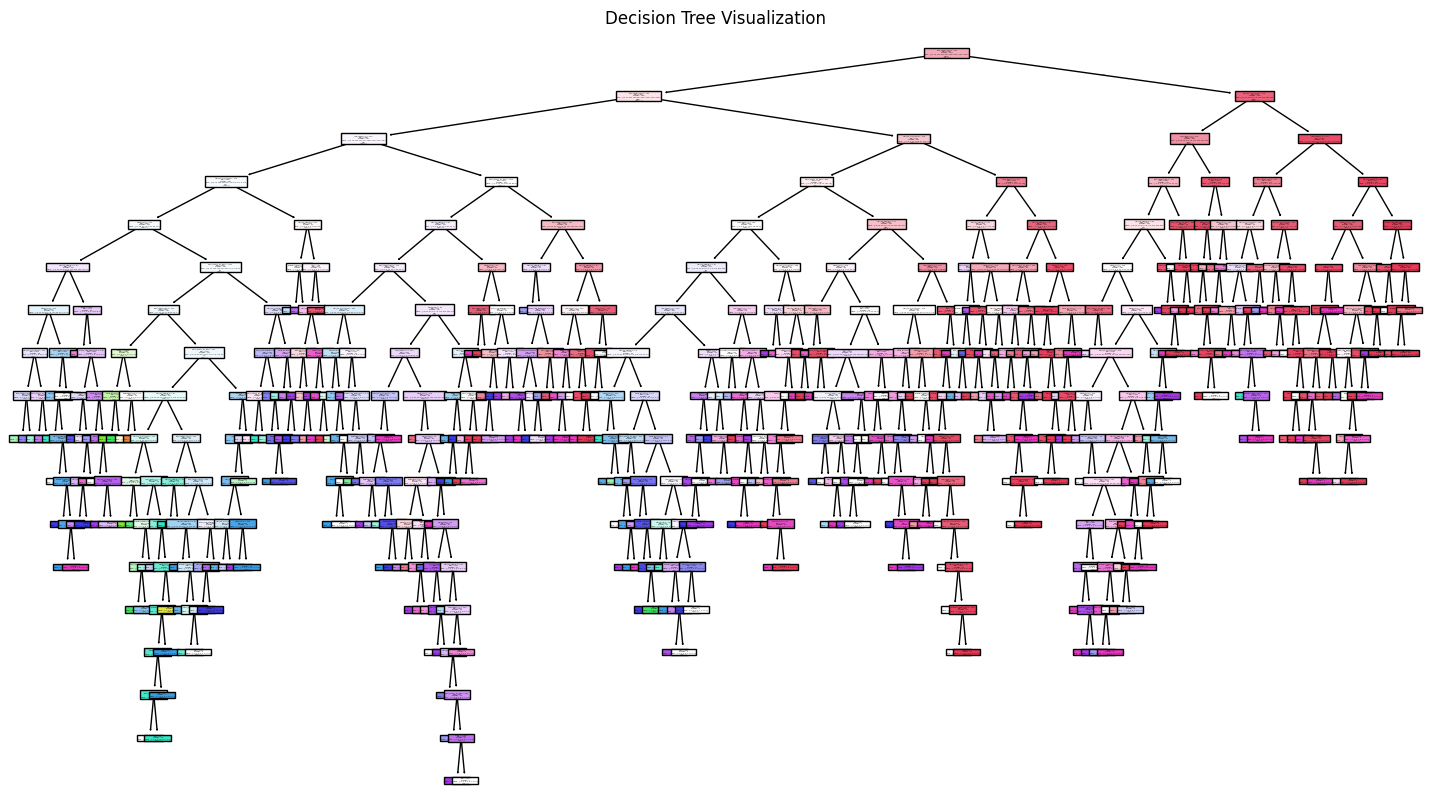

In [18]:
# Visualize Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(best_model, feature_names=X.columns, class_names=[str(cls) for cls in best_model.classes_], filled=True)
plt.title("Decision Tree Visualization")
plt.show()


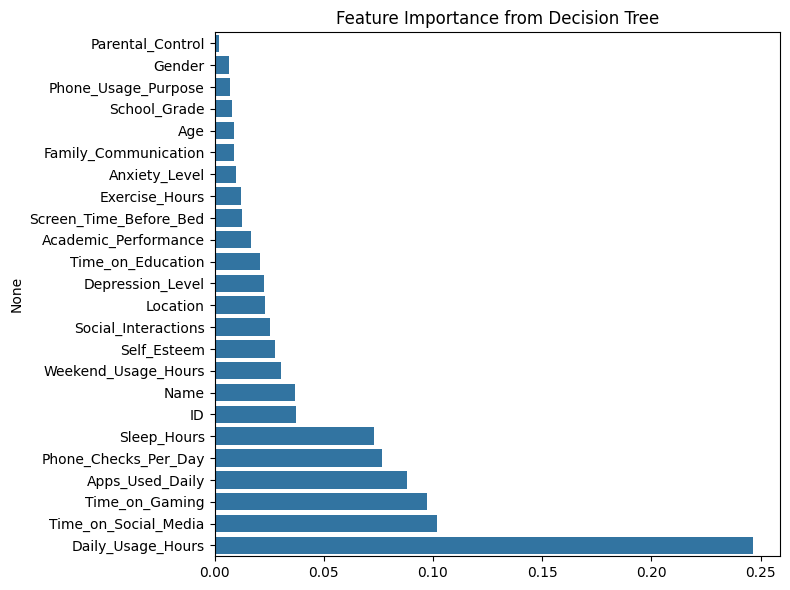

In [15]:
#Feature  Importance
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Decision Tree")
plt.tight_layout()
plt.show()

In [16]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances
# Show hidden outpu

Parental_Control          0.001975
Gender                    0.006412
Phone_Usage_Purpose       0.007224
School_Grade              0.007961
Age                       0.008689
Family_Communication      0.008921
Anxiety_Level             0.009793
Exercise_Hours            0.012032
Screen_Time_Before_Bed    0.012661
Academic_Performance      0.016651
Time_on_Education         0.020660
Depression_Level          0.022742
Location                  0.022926
Social_Interactions       0.025273
Self_Esteem               0.027839
Weekend_Usage_Hours       0.030366
Name                      0.036846
ID                        0.037168
Sleep_Hours               0.073178
Phone_Checks_Per_Day      0.076686
Apps_Used_Daily           0.088254
Time_on_Gaming            0.097439
Time_on_Social_Media      0.101787
Daily_Usage_Hours         0.246514
dtype: float64

In [17]:
print("\nSummary:")
print(f"Decision Tree trained using best parameters: {grid.best_params_}")
print(f"Accuracy after balancing and tuning: {acc:.2f}")
print("Confusion matrix, feature importance, and tree structure were visualized.")
print("Model and tree file are saved for future use.")


Summary:
Decision Tree trained using best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
Accuracy after balancing and tuning: 0.53
Confusion matrix, feature importance, and tree structure were visualized.
Model and tree file are saved for future use.


In [19]:
# Decision Tree Regressor
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load Dataset
df = pd.read_csv("teen_phone_addiction_dataset.csv")

# Drop missing values (if any)
df = df.dropna()

# Target column
target_col = "Addiction_Level"

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Decision Tree Regressor
reg = DecisionTreeRegressor(random_state=42)

# Hyperparameter tuning with GridSearchCV
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["squared_error", "friedman_mse", "absolute_error"]
}

grid_search = GridSearchCV(reg, param_grid, cv=5, scoring="r2")
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [21]:
# Best model
best_reg = grid_search.best_estimator_

# Predictions
y_pred = best_reg.predict(X_test)

# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 7, 'min_samples_split': 10}
R2 Score: 0.6220356644691306
Mean Squared Error: 0.9522105480313556
Root Mean Squared Error: 0.9758127627938444


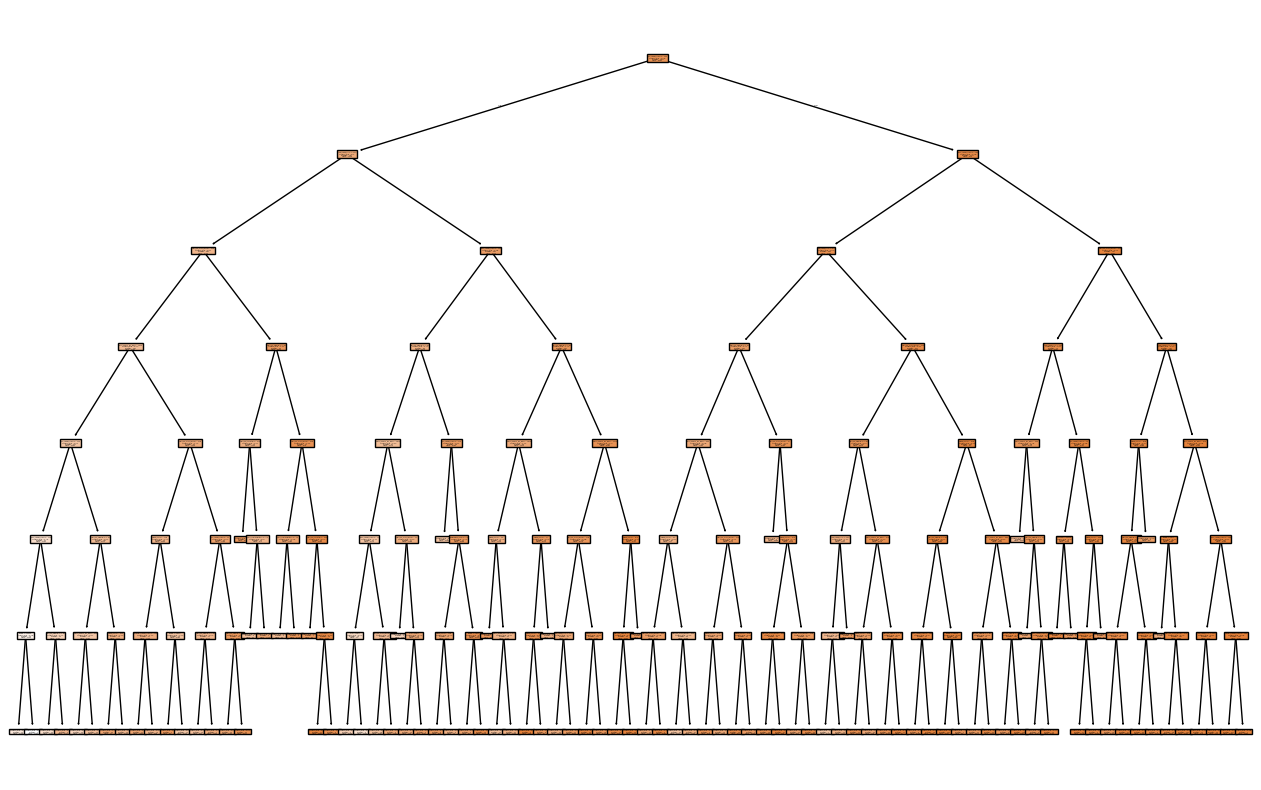

In [22]:
# Plot Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(best_reg, feature_names=X.columns, filled=True)
plt.show()

In [23]:
original_list = [10, 20, 20, 30, 40, 50, 50, 60, 70, 70, 70, 80]
result = list(set(original_list))
print(f"Original: {original_list}")
print(f"Without Duplicates: {result}")

Original: [10, 20, 20, 30, 40, 50, 50, 60, 70, 70, 70, 80]
Without Duplicates: [70, 40, 10, 80, 50, 20, 60, 30]
